In [1]:
"""
🔹 Step-by-Step Task Breakdown
Environment Setup: Import required libraries (pandas, numpy, scikit-learn, matplotlib).

Data Ingestion & Preprocessing: Load the .txt file without headers, assign the correct column names, and separate features (X) from the target variable (y).

Train-Test Splitting: Divide the dataset into 70% training and 30% testing subsets.

Exercise 1: Full-Feature Model Training: Initialize Logistic Regression with C=100, fit on training data.
Exercise 1: Model Evaluation: Predict on test data, calculate accuracy, and count misclassified samples.

Exercise 2: Feature Subset Extraction: Isolate only PrefixSuffix- (index 5) and AnchorURL (index 13).
Exercise 2: Subset Model Training & Comparison: Train a new LR model on the 2 features, compute accuracy, and compare with Exercise 1.
Exercise 2: Decision Boundary Visualization: Create a 2D meshgrid, predict class probabilities across the grid, and plot the decision boundary overlaid with test samples.
"""

'\n🔹 Step-by-Step Task Breakdown\nEnvironment Setup: Import required libraries (pandas, numpy, scikit-learn, matplotlib).\n\nData Ingestion & Preprocessing: Load the .txt file without headers, assign the correct column names, and separate features (X) from the target variable (y).\n\nTrain-Test Splitting: Divide the dataset into 70% training and 30% testing subsets.\n\nExercise 1: Full-Feature Model Training: Initialize Logistic Regression with C=100, fit on training data.\nExercise 1: Model Evaluation: Predict on test data, calculate accuracy, and count misclassified samples.\n\nExercise 2: Feature Subset Extraction: Isolate only PrefixSuffix- (index 5) and AnchorURL (index 13).\nExercise 2: Subset Model Training & Comparison: Train a new LR model on the 2 features, compute accuracy, and compare with Exercise 1.\nExercise 2: Decision Boundary Visualization: Create a 2D meshgrid, predict class probabilities across the grid, and plot the decision boundary overlaid with test samples.\n'

In [2]:
# Import libraries
# Working with scikit-learn libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
# Using the header provide in the document "Phishing Dectector using LR.pdf", modified first 2 columns' name, there are 31 columns

# The dictionary give 31 names, mapped to the dataset 

headers = [
    'Using_IP', 'Long_URL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-',
    'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL',
    'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail',
    'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
    'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
    'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class'
]

# Load dataset. Adjust sep=',' to sep='\s+' if your file is space/tab delimited.

# header=None tells pandas that the very first row is actual data, not the names of the columns (like "URL_Length", "Has_SSL", etc.). Because there are no names, pandas will automatically name your columns 0, 1, 2, 3... in this case the last # is 30

# By explicitly writing sep=',' you are telling Python: Even though this is a text file, the data inside is structured like a CSV, and columns are split by commas.

df = pd.read_csv('phishing_dataset.txt', header=None, sep=',')

# takes a list of strings (stored in the variable headers) and overwrites the current column labels of the DataFrame from left to right
df.columns = headers

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (11055, 31)
   Using_IP  Long_URL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0        -1         1         1        1             -1             -1   
1         1         1         1        1              1             -1   
2         1         0         1        1              1             -1   
3         1         0         1        1              1             -1   
4         1         0        -1        1              1             -1   

   SubDomains  HTTPS  DomainRegLen  Favicon  ...  UsingPopupWindow  \
0          -1     -1            -1        1  ...                 1   
1           0      1            -1        1  ...                 1   
2          -1     -1            -1        1  ...                 1   
3          -1     -1             1        1  ...                 1   
4           1      1            -1        1  ...                -1   

   IframeRedirection  AgeofDomain  DNSRecording  WebsiteTraffic  PageRank  \
0                  1          

In [4]:
    # Per document instruction, separate features (first 30 columns) and target (last column)

    # iloc means "integer location" (pulling data by position numbers)

    # [:, :-1] means: take all rows (the :), and take all columns EXCEPT the last one (the :-1)

    # The "What You Know" pile
X = df.iloc[:, :-1]

    # The "What You Want to Predict" pile
    # [:, -1] means: take all rows (the :), and take ONLY THE LAST COLUMN (the -1)
y = df.iloc[:, -1]   # 'class' column: 1 (phishing) or -1 (legitimate)



    # This is called "tuple unpacking" - think of it like this:

    # The train_test_split function doesn't return just ONE thing - it returns FOUR things all packaged together. The equals sign = assigns each returned thing to a variable in order:

    # X_train + y_train = The "homework" (teach the AI using these)

    # X_test + y_test = The "exam" (test if AI actually learned)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 7738, Test size: 3317


In [5]:
"""
    C=100	Low regularization	"Trust the training data a lot" (fits closely) *** Regularization prevents the model from memorizing instead of learning ***
 
    Low C (like 0.01) = High regularization → Model keeps things simple (might underperform)

    High C (like 100) = Low regularization → Model fits training data very closely (yours)

    C=1 = Default / balanced approach

    Think of it like studying for a test:

    Low C = Studying general concepts (might miss details)

    High C = Memorizing every practice problem (risks failing if test questions change slightly)

"""

# random_state=42	Fixed randomness	"Give me the same random results every time I run this"
# max_iter=1000	Max learning attempts	"Try up to 1000 times to find the best answer"

lr_full = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_full.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:

"""
    accuracy_score calculates (Correct Predictions) / (Total Predictions).

    (y_test != y_pred_full).sum() leverages boolean masking to count mismatches efficiently without loops.
    
    Accuracy alone can be misleading in imbalanced datasets, but for this phishing dataset (usually ~50/50 split), it's a valid primary metric.

"""

y_pred_full = lr_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
misclassified_full = (y_test != y_pred_full).sum()

print(f"🔹 Exercise 1 Results (All 30 Features):")
print(f"   Accuracy: {accuracy_full:.4f} ({accuracy_full*100:.2f}%)")
print(f"   Misclassified Samples: {misclassified_full} out of {len(y_test)}")

🔹 Exercise 1 Results (All 30 Features):
   Accuracy: 0.9298 (92.98%)
   Misclassified Samples: 233 out of 3317


In [7]:
# Exercise 2: Subset to 2 Features

# Explanation & Reasoning:
# Intentionally drop 28 features to observe how much predictive power is lost. This simulates real-world feature selection where simpler models are preferred for interpretability and speed.

# Extract only index 5 (PrefixSuffix-) and index 13 (AnchorURL)
X_train_2 = X_train.iloc[:, [5, 13]]
X_test_2 = X_test.iloc[:, [5, 13]]

In [8]:
#  Explanation & Reasoning:
# By comparing accuracy_full vs accuracy_2, we quantify the information loss from dropping 28 features.
# If accuracy drops significantly, it implies those features contain non-linear or complementary signals. If it stays similar, the two features are highly predictive on their own.


lr_two = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_two.fit(X_train_2, y_train)

y_pred_2 = lr_two.predict(X_test_2)
accuracy_2 = accuracy_score(y_test, y_pred_2)
misclassified_2 = (y_test != y_pred_2).sum()

print(f"\n🔹 Exercise 2 Results (2 Features Only):")
print(f"   Accuracy: {accuracy_2:.4f} ({accuracy_2*100:.2f}%)")
print(f"   Misclassified Samples: {misclassified_2} out of {len(y_test)}")
print(f"   Accuracy Drop: {accuracy_full - accuracy_2:.4f}")


🔹 Exercise 2 Results (2 Features Only):
   Accuracy: 0.8444 (84.44%)
   Misclassified Samples: 516 out of 3317
   Accuracy Drop: 0.0853


c:\Users\SETUP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


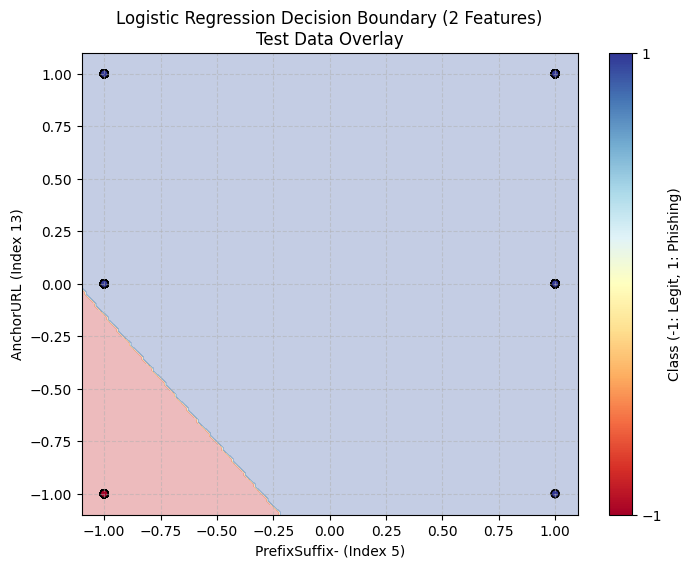

In [9]:
# Create a meshgrid covering the range of both features
x_min, x_max = X_test_2.iloc[:, 0].min() - 0.1, X_test_2.iloc[:, 0].max() + 0.1
y_min, y_max = X_test_2.iloc[:, 1].min() - 0.1, X_test_2.iloc[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the entire grid
Z = lr_two.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')  # Decision regions
scatter = plt.scatter(X_test_2.iloc[:, 0], X_test_2.iloc[:, 1], 
                      c=y_test, edgecolor='k', cmap='RdYlBu', s=30)
plt.colorbar(scatter, ticks=[-1, 1], label='Class (-1: Legit, 1: Phishing)')
plt.xlabel('PrefixSuffix- (Index 5)')
plt.ylabel('AnchorURL (Index 13)')
plt.title('Logistic Regression Decision Boundary (2 Features)\nTest Data Overlay')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()